# What is an Oscillator?

An oscillator is basically an object connected to a spring. When this object is pushed or pulled, it will start to move back and forth. This movement of the object is called **oscillation**, as it moves back and forth around a central point a.k.a. the **equilibrium position**.

In an ideal situation, the object will keep oscillating forever. However, in real life, there are forces like friction and air resistance that cause the object to eventually stop moving. This is called **damping**.

<!-- add image of a simple mass-spring system -->

When working with oscillators, we often use a mathematical model called the **harmonic oscillator**. This model describes the motion of an ideal oscillator without any damping or external forces. The equation for a harmonic oscillator is:
$$\frac{d^2x}{dt^2} + \omega^2 x = 0$$
where $x$ is the displacement of the oscillator from its equilibrium position, $t$ is time, and $\omega$ is the angular frequency of the oscillator. The solution to this equation is a sinusoidal function, which describes the oscillatory motion of the system.

<!-- add image of a harmonic oscillator with sine wave -->

As stated earlier, in real life, oscillators are not ideal and are subject to damping and external forces. The equation for a damped harmonic oscillator is:
$$\frac{d^2x}{dt^2} + \beta \frac{dx}{dt} + \omega^2 x = 0$$
where $\beta$ is the damping coefficient. The solution to this equation depends on the value of $\beta$ and can describe different types of motion, such as underdamped, overdamped, or critically damped oscillations.

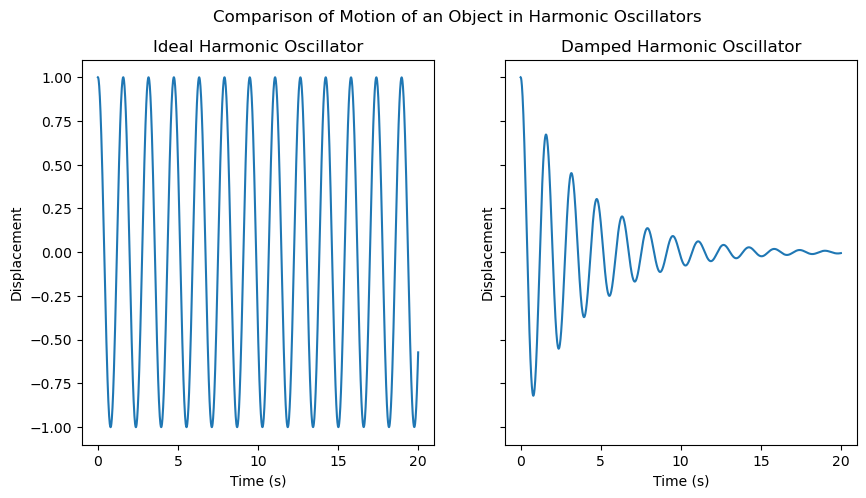

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

def harmonic_oscillator(t, y, omega):
    x, v = y
    dxdt = v
    dvdt = -omega**2 * x
    return [dxdt, dvdt]

def damped_harmonic_oscillator(t, y, omega, beta):
    x, v = y
    dxdt = v
    dvdt = -beta * v - omega**2 * x
    return [dxdt, dvdt]

# Parameters
A = 1.0      # Amplitude
k = 4 * np.pi**2  # Spring constant
m = 2.5      # Mass
omega = np.sqrt(k / m)  # Natural frequency
beta = 0.5  # Damping coefficient for underdamped case
t = np.linspace(0, 20, 2000)  # Time array

# Initial condition
y = [A, 0]  # Initial displacement and velocity

# Compute the damped harmonic oscillator
x_ideal = solve_ivp(harmonic_oscillator, (t[0], t[-1]), y, args=(omega,), t_eval=t).y[0]
x_under = solve_ivp(damped_harmonic_oscillator, (t[0], t[-1]), y, args=(omega, beta), t_eval=t).y[0]

# Plotting
fig, ax = plt.subplots(1, 2, figsize=(10, 5), sharey=True)
ax[0].plot(t, x_ideal)
ax[0].set_title('Ideal Harmonic Oscillator')
ax[0].set_xlabel('Time (s)')
ax[0].set_ylabel('Displacement')

ax[1].plot(t, x_under)
ax[1].set_title('Damped Harmonic Oscillator')
ax[1].set_xlabel('Time (s)')
ax[1].set_ylabel('Displacement')

fig.suptitle('Comparison of Motion of an Object in Harmonic Oscillators')
plt.show()

In the two cases above, we do not have any external forces acting on the system. We have only put the system into motion by giving it an initial push. This is called **free oscillation**.

Let's see what happens when we provide some input force to the system. This is called **forced oscillation**. The equation for such an oscillator is:

$$\frac{d^2x}{dt^2} + \beta \frac{dx}{dt} + \omega^2 x = f(t)$$

where $f(t)$ is the external driving force.

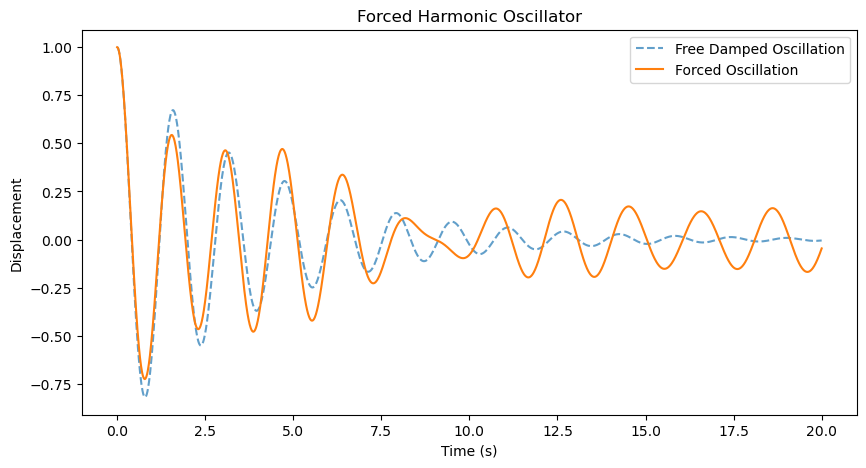

In [3]:
def forced_harmonic_oscillator(t, y, omega, beta, F0, omega_d):
    x, v = y
    dxdt = v
    Ft = F0 * np.sin(omega_d * t)
    dvdt = (Ft / m) - beta * v - omega**2 * x
    return [dxdt, dvdt]

# Parameters for forced oscillator
F0 = 2.5  # Amplitude of driving force
omega_d = np.pi  # Driving frequency

# Compute the forced harmonic oscillator
x_forced = solve_ivp(forced_harmonic_oscillator, (t[0], t[-1]), y, args=(omega, beta, F0, omega_d), t_eval=t).y[0]

# Plotting the forced harmonic oscillator
plt.figure(figsize=(10, 5))
plt.plot(t, x_under, '--', label='Free Damped Oscillation', alpha=0.7)
plt.plot(t, x_forced, label='Forced Oscillation')
plt.title('Forced Harmonic Oscillator')
plt.xlabel('Time (s)')
plt.ylabel('Displacement')
plt.legend()
plt.show()

When we apply a periodic driving force to the free damped oscillator, it can sustain the oscillations for a longer time. This is because the driving force provides energy to the system, which can compensate for the energy lost due to damping. The resulting motion of the system will depend on the frequency and amplitude of the driving force, as well as the natural frequency and damping of the oscillator..

# Coupled Oscillators

Until now, we have considered single oscillators. When we connect two or more such oscillators together, they are called **coupled oscillators**. The coupling is usually achieved through direct mechanical connection, such as springs, or through electrical circuits, or even through the medium of sound waves.

Here's an example of a coupled oscillators:
<!-- add image of a coupled oscillators -->

In this system, the motion of one oscillator can affect the motion of the other. For example, if one oscillator is displaced from its equilibrium position, it causes the other oscillator to start oscillating as well. This is because the coupling allows energy to be transferred between the two oscillators.

This system can be described by a set of coupled differential equations. For two coupled oscillators, the equations are:
$$\frac{d^2x_1}{dt^2} + \beta_1 \frac{dx_1}{dt} + \omega_1^2 x_1 = f_1(t) + c_{12} (x_2 - x_1) $$
$$\frac{d^2x_2}{dt^2} + \beta_2 \frac{dx_2}{dt} + \omega_2^2 x_2 = f_2(t) + c_{12} (x_1 - x_2) $$
where $x_1$ and $x_2$ are the displacements of the two oscillators, $c_{12}$ is the coupling constant, $\beta_1$, $\beta_2$ are the damping coefficients, $\omega_1$, $\omega_2$ are the natural frequencies of the oscillators, and $f_1(t)$, $f_2(t)$ are the external driving forces.

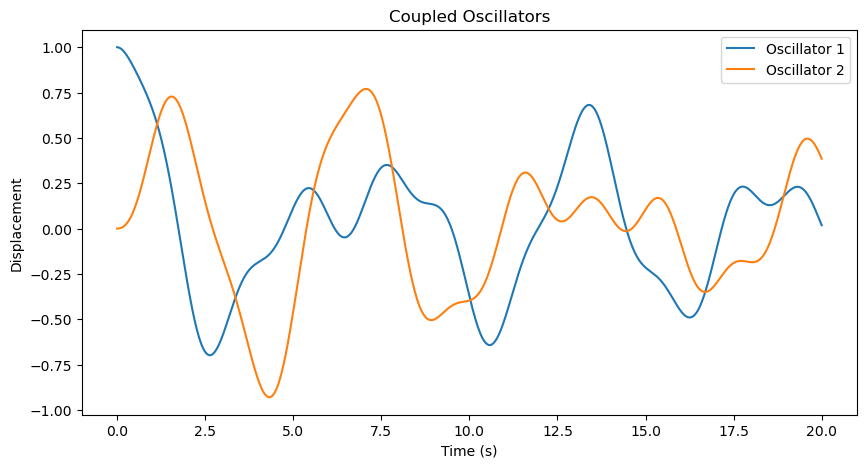

In [4]:
def coupled_oscillators(t, y, k, m, beta, c12, F0_1, F0_2, omega_d_1, omega_d_2):
    x1, v1, x2, v2 = y
    F1 = F0_1 * np.sin(omega_d_1 * t)
    F2 = F0_2 * np.sin(omega_d_2 * t)
    dx1dt = v1
    dv1dt = -beta * v1 - (k/m) * x1 + c12 * (x2 - x1) + F1 / m
    dx2dt = v2
    dv2dt = -beta * v2 - (k/m) * x2 + c12 * (x1 - x2) + F2 / m
    return [dx1dt, dv1dt, dx2dt, dv2dt]

# Parameters for coupled oscillators
k = 1.0  # Coupling strength
m = 1.0  # Mass of each oscillator
omega = np.sqrt(k / m)  # Natural frequency of each oscillator
beta = 0.1  # Damping coefficient for underdamped case
c12 = 0.5  # Coupling constant
F0_1 = 1.0  # Amplitude of driving force for oscillator 1
F0_2 = 1.0  # Amplitude of driving force for oscillator 2
omega_d_1 = np.pi  # Driving frequency for oscillator 1
omega_d_2 = np.pi  # Driving frequency for oscillator 2
y0 = [1.0, 0.0, 0.0, 0.0]  # Initial conditions: [x1, v1, x2, v2]
t_span = (0, 20)
t_eval = np.linspace(*t_span, 1000)

# Solve the coupled oscillators
sol = solve_ivp(coupled_oscillators, t_span, y0, args=(k, m, beta, c12, F0_1, F0_2, omega_d_1, omega_d_2), t_eval=t_eval)

# Plotting the coupled oscillators
plt.figure(figsize=(10, 5))
plt.plot(sol.t, sol.y[0], label='Oscillator 1')
plt.plot(sol.t, sol.y[2], label='Oscillator 2')
plt.title('Coupled Oscillators')
plt.xlabel('Time (s)')
plt.ylabel('Displacement')
plt.legend()
plt.show()

## So what happens when you couple numerous oscillators together?

When you couple a large number of oscillators together, you can get even more complex behavior. You can get the entire system of oscillators to do various computations for you, such as pattern recognition, signal processing, and even machine learning tasks. This is the basis of **physical reservoir computing**, where a large network of coupled oscillators can be used to perform complex computations by leveraging their dynamic behavior.

Consider you have $N$ oscillators coupled to each other, each with its own coupling strength, damping constant, and input force or signal. In such cases, the equation governing the motion of each $i^{th}$ oscillator can be written as:

$$\frac{d^2x_i}{dt^2} + \beta_i \frac{dx_i}{dt} + \omega_i^2 x_i = f_i(t) + \sum_{j=1}^{N} c_{ij} (x_j - x_i)$$

where $x_i$ is the displacement, $\beta_i$ is the damping coefficient, $\omega_i$ is the natural frequency, $f_i(t)$ is the external driving force, and $c_{ij}$ is the coupling strength between the $i^{th}$ and $j^{th}$ oscillators. The term $\sum_{j=1}^{N} c_{ij} (x_j - x_i)$ represents the influence of all other oscillators on the $i^{th}$ oscillator due to coupling.

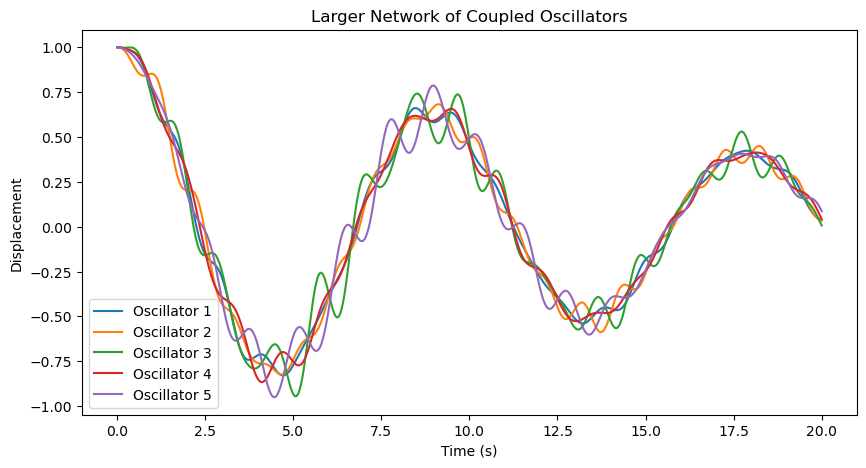

In [29]:
def coupled_oscillators(t, y, k_matrix, m, beta_matrix, F0, omega_d, F_matrix, c_matrix):
    N = len(y) // 2
    x = y[:N]
    v = y[N:]

    dxdt = v
    dvdt = np.zeros(N)
    for i in range(N):
        Ft = F_matrix[i] * np.sin(omega_d * t)
        coupling_term = sum(c_matrix[i, j] * (x[j] - x[i]) for j in range(N))
        dvdt[i] = - beta_matrix[i] * v[i] - (k_matrix[i, i] / m) * x[i] + coupling_term + Ft / m
    
    
    return np.concatenate([dxdt, dvdt])

# Parameters for a larger network of coupled oscillators
N = 5  # Number of oscillators
k_matrix = np.full((N, N), 0.5)  # Spring constant matrix
m = 1.0  # Mass of each oscillator
beta_matrix = np.full(N, 0.1)  # Damping coefficients

F0 = 1.0
omega_d = 2 * np.pi  # Driving frequency
seed = 56
rng = np.random.default_rng(seed)
F_matrix = rng.uniform(-1.0, 1.0, N)
# F_matrix = np.random.rand(N)# * 2 * np.pi  # Random driving frequencies
seed = 268
rng = np.random.default_rng(seed)
c_matrix = rng.uniform(0, 10, (N, N))  # Random coupling strengths
c_matrix = c_matrix - np.diag(np.diag(c_matrix))  # Remove self-coupling
y0 = np.concatenate([np.ones(N), np.zeros(N)])  # Initial conditions: [x1, x2, ..., v1, v2, ...]
t_span = (0, 20)
t_eval = np.linspace(*t_span, 1000)

# Solve the larger network of coupled oscillators
sol = solve_ivp(coupled_oscillators, t_span, y0, args=(k_matrix, m, beta_matrix, F0, omega_d, F_matrix, c_matrix), t_eval=t_eval)

# Plotting the larger network of coupled oscillators
plt.figure(figsize=(10, 5))
for i in range(N):
    plt.plot(sol.t, sol.y[i], label=f'Oscillator {i+1}')
plt.title('Larger Network of Coupled Oscillators')
plt.xlabel('Time (s)')
plt.ylabel('Displacement')
plt.legend()
plt.show()

In the above case, I used a very small number of coupled oscillators and randomly set the parameters. Now let's look at what happens when I carefully choose the parameters and increase the number of oscillators. Instead of having different input per oscillator, I will have a single input that is fed into all the oscillators but with different strengths.

Spectral radius: 0.180
State range: [-0.966, 0.967]
State std: 0.263


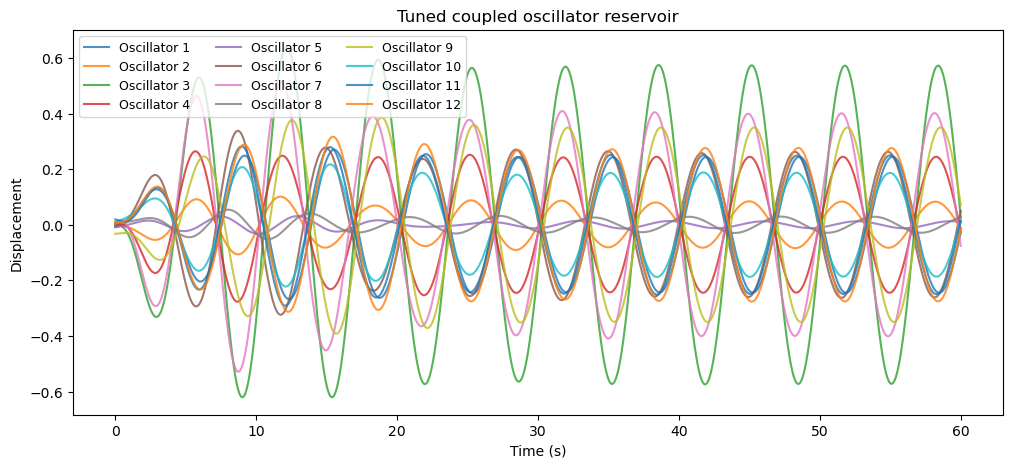

In [ ]:
def drive_signal(t, omega_d):
    return np.sin(omega_d * t) #+ 0.25 * np.sin(2.1 * omega_d * t + 0.4)

def coupled_oscillators(t, y, k_matrix, m, beta_matrix, F0, omega_d, F_matrix, c_matrix):
    N = len(y) // 2
    x = y[:N]
    v = y[N:]

    dxdt = v
    dvdt = np.zeros(N)
    drive = drive_signal(t, omega_d)
    for i in range(N):
        Ft = F_matrix[i] * F0 * drive
        coupling_term = np.sum(c_matrix[i] * (x - x[i]))
        dvdt[i] = -beta_matrix[i] * v[i] - (k_matrix[i, i] / m) * x[i] + coupling_term + Ft / m

    return np.concatenate([dxdt, dvdt])

# Tuned parameters for a bounded, diverse reservoir response
N = 128
m = 1.0
seed = 56
rng = np.random.default_rng(seed)

beta_matrix = rng.uniform(0.18, 0.28, N)
omega_n = rng.uniform(1.0, 1.3, N)
k_matrix = np.diag(m * omega_n**2)

omega_d = 0.95
F0 = 0.35
F_matrix = rng.uniform(-1.0, 1.0, N)

seed = 268
rng = np.random.default_rng(seed)
c_matrix = rng.uniform(0.0, 0.03, (N, N))
mask = rng.random((N, N)) < 0.06
np.fill_diagonal(mask, False)
c_matrix = c_matrix * mask
c_matrix = 0.5 * (c_matrix + c_matrix.T)
np.fill_diagonal(c_matrix, 0.0) # Remove self-coupling

raw_radius = max(abs(np.linalg.eigvals(c_matrix)))
target_spectral_radius = 0.18
if raw_radius > 0:
    c_matrix *= target_spectral_radius / raw_radius
spectral_radius = max(abs(np.linalg.eigvals(c_matrix)))
assert spectral_radius < 1.0, f"Spectral radius is {spectral_radius}, which is not less than 1."

y0 = 0.01 * rng.standard_normal(2 * N)
t_span = (0.0, 60.0)
t_eval = np.linspace(*t_span, 3000)

sol = solve_ivp(
    coupled_oscillators,
    t_span,
    y0,
    args=(k_matrix, m, beta_matrix, F0, omega_d, F_matrix, c_matrix),
    t_eval=t_eval,
    max_step=0.05,
    rtol=1e-6,
    atol=1e-8,
 )

assert sol.success, sol.message
X = sol.y[:N].T
input_trace = drive_signal(sol.t, omega_d)

print(f"Spectral radius: {spectral_radius:.3f}")
print(f"State range: [{X.min():.3f}, {X.max():.3f}]")
print(f"State std: {X.std():.3f}")

fig, ax = plt.subplots(1, 1, figsize=(12, 5))
for i in range(12):
    ax.plot(sol.t, X[:, i], label=f"Oscillator {i + 1}", alpha=0.8)
ax.set_title("Tuned coupled oscillator reservoir")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Displacement")
ax.legend(ncol=3, fontsize=9)
plt.show()

This output looks quite different from the previous one

Task: delayed input reconstruction (40 steps / 0.800 s)
State features: reservoir displacements X with shape (3000, 128)
Train/test split: 1931/829 samples
Ridge alpha: 0.01
Test R^2: 1.000
Test NMSE: 0.000


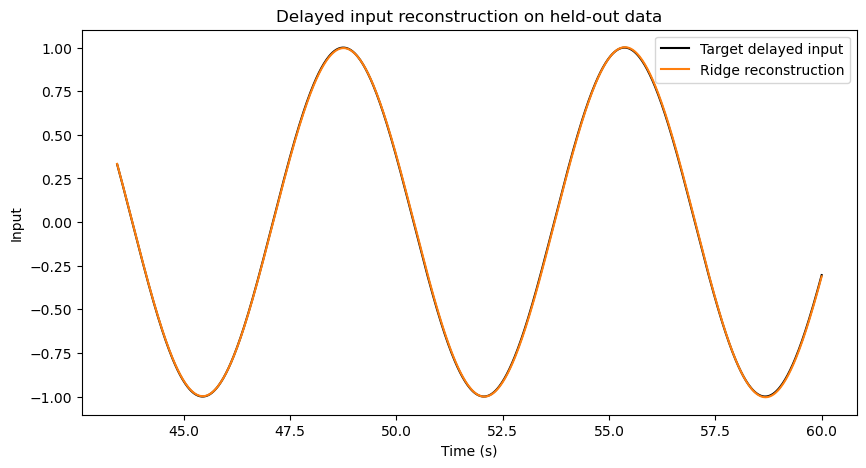

In [7]:
# Delayed input reconstruction on the tuned reservoir states
washout = 200
delay_steps = 40
train_fraction = 0.7
ridge_alpha = 1e-2

X_eval = X[washout:]
u_eval = input_trace[washout:]

if delay_steps >= len(u_eval):
    raise ValueError("delay_steps is too large for the available time series length.")

X_delayed = X_eval[delay_steps:]
u_target = u_eval[:-delay_steps]

n_samples = len(u_target)
train_size = int(train_fraction * n_samples)

X_train = X_delayed[:train_size]
X_test = X_delayed[train_size:]
y_train = u_target[:train_size]
y_test = u_target[train_size:]

X_train_aug = np.column_stack([X_train, np.ones(len(X_train))])
X_test_aug = np.column_stack([X_test, np.ones(len(X_test))])

identity = np.eye(X_train_aug.shape[1])
identity[-1, -1] = 0.0  # do not regularize bias
weights = np.linalg.solve(
    X_train_aug.T @ X_train_aug + ridge_alpha * identity,
    X_train_aug.T @ y_train,
 )

y_pred = X_test_aug @ weights
baseline_pred = np.full_like(y_test, y_train.mean())

def r2_score(y_true, y_hat):
    ss_res = np.sum((y_true - y_hat) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan

def nmse(y_true, y_hat):
    return np.mean((y_true - y_hat) ** 2) / np.var(y_true)

r2 = r2_score(y_test, y_pred)
baseline_r2 = r2_score(y_test, baseline_pred)
test_nmse = nmse(y_test, y_pred)
baseline_nmse = nmse(y_test, baseline_pred)

print(f"Task: delayed input reconstruction ({delay_steps} steps / {delay_steps * (t_eval[1] - t_eval[0]):.3f} s)")
print(f"State features: reservoir displacements X with shape {X.shape}")
print(f"Train/test split: {train_size}/{len(y_test)} samples")
print(f"Ridge alpha: {ridge_alpha}")
print(f"Test R^2: {r2:.3f}")
print(f"Test NMSE: {test_nmse:.3f}")

test_time = sol.t[washout + delay_steps + train_size : washout + delay_steps + n_samples]

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(test_time, y_test, label="Target delayed input", color="black", linewidth=1.5)
ax.plot(test_time, y_pred, label="Ridge reconstruction", color="tab:orange")
ax.set_title("Delayed input reconstruction on held-out data")
ax.set_ylabel("Input")
ax.set_xlabel("Time (s)")
ax.legend()
plt.show()